In [ ]:
# 下载
import pandas as pd
import earthaccess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

# 登录 NASA Earthdata
auth = earthaccess.login()

# 配置
CSV_PATH = "/data2/yuyao/methane_emission/preprocess_dataset_L89/merged_with_emit_tag.csv"
EMIT_RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT")
EMIT_RAW_DIR.mkdir(exist_ok=True)

# 1. 筛选数据
df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['datetime'])

# 筛选条件：Permian Basin 范围 + 时间 < 2024-12-31
# Permian 典型范围: Lat [30, 34], Lon [-105, -101]
mask = (
    (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 34) &
    (df['plume_longitude'] >= -105) & (df['plume_longitude'] <= -101) &
    (df['datetime'] <= "2024-12-31") &
    (df['has_emit'] == 1)
)
filtered_df = df[mask].drop_duplicates(subset=['emit_granule_id'])

print(f"找到待下载的独特 EMIT 颗粒数量: {len(filtered_df)}")

def download_granule(granule_id):
    """修复后的单任务下载函数"""
    # 检查本地是否已存在，避免重复下载
    if list(EMIT_RAW_DIR.glob(f"*{granule_id}*.nc")):
        return f"{granule_id} 已存在"
    
    # 关键点：必须指定 short_name 或 collection_concept_id
    results = earthaccess.search_data(
        short_name='EMITL2ARFL',  # 显式限定为 EMIT L2A 反射率产品
        granule_name=granule_id,
        count=1
    )
    
    if results:
        earthaccess.download(results, str(EMIT_RAW_DIR))
        return f"{granule_id} 下载完成"
    return f"{granule_id} 未找到"

# 使用线程池加速下载
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(executor.map(download_granule, filtered_df['emit_granule_id']))

找到待下载的独特 EMIT 颗粒数量: 79


QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 2362.99it/s]
QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 391.21it/s]

QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 1185.50it/s]


QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 2693.84it/s]





QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 2541.49it/s]







QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 2866.27it/s]















QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 789.24it/s]





QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 229.70it/s]



























PROCESSING TASKS | :  33%|███▎      | 1/3 [01:22<02:45, 82.73s/it]



PROCESSING TASKS | :  67%|██████▋   | 2/3 [04:56<02:39, 159.61s/it]








PROCESSING TASKS | : 100%|██████████| 3/3 [05:09<00:00, 103.31s/it]




COLLECTING RESULTS | : 100%|██████████| 3/3 [00:00<00:00, 65879.12it/s]




QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 2232.60it/s]








PROCESSING TASKS | : 100%|██████████

In [ ]:
# convert EMIT to L9, 60m with optimized band alignment
import os
import gc
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import earthaccess
import cupy as cp
from pathlib import Path
from pyproj import Transformer
from scipy.spatial import KDTree as CPU_KDTree

os.umask(0) # 允许创建的文件拥有最大权限 (777)
# ==================== 用户配置区 ====================
CSV_PATH = "./merged_with_emit_tag.csv"
SRF_CSV = "./landsat9_oli_srf.csv"
EMIT_RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT")
OUTPUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm")

CHIP_SIZE_PX = 512    
SCALE_M = 60          
# ===================================================

EMIT_RAW_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# Login to NASA Earthdata
auth = earthaccess.login()

def get_utm_crs(lat, lon):
    zone = int((lon + 180) / 6) + 1
    return f"EPSG:{32600 + zone if lat >= 0 else 32700 + zone}"

def download_emit_granule(granule_id):
    existing = list(EMIT_RAW_DIR.glob(f"*{granule_id}*RFL*.nc"))
    if existing: return existing[0]
    
    results = earthaccess.search_data(short_name='EMITL2ARFL', granule_name=granule_id)
    if not results: return None
    
    links = [link for link in results[0].data_links() if "UNCERT" not in link and "RFL" in link]
    files = earthaccess.download(links, str(EMIT_RAW_DIR))
    return Path(files[0]) if files else None

def get_spectral_matrix(emit_waves, srf_df):
    matrix = np.zeros((len(emit_waves), 7))
    for i in range(1, 8):
        w = np.interp(emit_waves, srf_df["wavelength"], srf_df[f"b{i}"], left=0, right=0)
        matrix[:, i-1] = w / (w.sum() + 1e-12)
    return cp.array(matrix)

def main():
    df = pd.read_csv(CSV_PATH)
    srf_df = pd.read_csv(SRF_CSV)
    
    # 筛选目标数据
    mask = (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 35) & (df['has_emit'] == 1)
    target_df = df[mask]
    
    print(f"Total tasks to process: {len(target_df)}")
    
    spectral_matrix = None 
    target_scales = [10100, 11100, 13100, 16100, 20100, 23100, 21100]

    for _, row in target_df.iterrows():
        plume_id = row['plume_id']
        out_tif = OUTPUT_DIR / f"{plume_id}_sim_L9.tif"
        
        if out_tif.exists():
            print(f"   [Skip] {plume_id} already exists.")
            continue

        rfl_path = download_emit_granule(row['emit_granule_id'])
        if not rfl_path: 
            print(f"   [Error] Could not download/find granule for {plume_id}")
            continue

        print(f"\n[Processing] {plume_id}")

        try:
            # 1. 空间范围裁剪计算
            with xr.open_dataset(rfl_path, group='location', engine='netcdf4') as ds_loc:
                lats, lons = ds_loc['lat'].values, ds_loc['lon'].values
                mask_spatial = (lats > row['plume_latitude'] - 0.15) & (lats < row['plume_latitude'] + 0.15) & \
                               (lons > row['plume_longitude'] - 0.15) & (lons < row['plume_longitude'] + 0.15)
                y_idxs, x_idxs = np.where(mask_spatial)
                
                if len(y_idxs) == 0:
                    print(f"   [Error] Plume {plume_id} not found in spatial extent.")
                    continue
                
                y_min, y_max, x_min, x_max = y_idxs.min(), y_idxs.max(), x_idxs.min(), x_idxs.max()
                lat_crop, lon_crop = lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max]

            # 2. 读取反射率并初始化卷积矩阵
            with xr.open_dataset(rfl_path, engine='netcdf4') as ds:
                rfl_crop = ds['reflectance'][y_min:y_max, x_min:x_max, :].values
                
            if spectral_matrix is None:
                with xr.open_dataset(rfl_path, group='sensor_band_parameters') as dsb:
                    spectral_matrix = get_spectral_matrix(dsb['wavelengths'].values, srf_df)

            # 3. GPU 卷积与分波段动态拉伸
            cp_rfl = cp.array(np.nan_to_num(rfl_crop, 0))
            sim_conv = cp.matmul(cp_rfl, spectral_matrix) # (Y, X, 7)
            
            cp_simulated_list = []
            for b in range(7):
                band_data = sim_conv[:, :, b]
                valid_mask = (band_data > 0)
                
                if valid_mask.any():
                    p_low = cp.percentile(band_data[valid_mask], 1)
                    p_high = cp.percentile(band_data[valid_mask], 99)
                    # 线性拉伸
                    stretched = (band_data - p_low) / (p_high - p_low + 1e-6)
                else:
                    stretched = band_data

                # 应用你调整后的参数：80% Offset + 60% Scale
                offset = target_scales[b] * 0.8
                final_band = (stretched * (target_scales[b] * 0.6)) + offset
                # 保持背景为0
                final_band = cp.where(band_data > 0, final_band, 0)
                cp_simulated_list.append(cp.clip(final_band, 0, 65535))
            
            cp_simulated = cp.stack(cp_simulated_list, axis=0) # (7, Y, X)

            # 4. 空间重采样 (KDTree)
            utm_epsg = get_utm_crs(row['plume_latitude'], row['plume_longitude'])
            to_utm = Transformer.from_crs("EPSG:4326", utm_epsg, always_xy=True)
            to_wgs = Transformer.from_crs(utm_epsg, "EPSG:4326", always_xy=True)
            
            center_x, center_y = to_utm.transform(row['plume_longitude'], row['plume_latitude'])
            half_size = (CHIP_SIZE_PX * SCALE_M) / 2
            target_x = np.linspace(center_x - half_size, center_x + half_size, CHIP_SIZE_PX)
            target_y = np.linspace(center_y + half_size, center_y - half_size, CHIP_SIZE_PX)
            
            mesh_x, mesh_y = np.meshgrid(target_x, target_y)
            t_lon, t_lat = to_wgs.transform(mesh_x, mesh_y)
            
            tree = CPU_KDTree(np.stack([lat_crop.ravel(), lon_crop.ravel()], axis=1))
            dist, indices = tree.query(np.stack([t_lat.ravel(), t_lon.ravel()], axis=1), distance_upper_bound=0.001)
            
            # 5. 映射与掩膜
            cp_indices = cp.array(indices)
            final_output = cp_simulated.reshape(7, -1)[:, cp_indices].reshape(7, CHIP_SIZE_PX, CHIP_SIZE_PX)
            invalid_mask = cp.array(dist == float('inf')).reshape(CHIP_SIZE_PX, CHIP_SIZE_PX)
            final_output[:, invalid_mask] = 0

            # 6. 保存为 TIF
            res_np = final_output.get().astype(np.uint16)
            sim_da = xr.DataArray(
                res_np,
                dims=("band", "y", "x"),
                coords={"band": np.arange(1, 8), "y": target_y, "x": target_x}
            )
            sim_da.rio.write_crs(utm_epsg, inplace=True)
            sim_da.rio.to_raster(out_tif)
            
            print(f"   [Success] Saved: {out_tif.name} | Mean: {res_np.mean():.0f}")

            # 清理显存和内存
            del cp_rfl, sim_conv, cp_simulated, cp_simulated_list, final_output, rfl_crop, tree, res_np, sim_da
            cp.get_default_memory_pool().free_all_blocks()
            gc.collect()

        except Exception as e:
            print(f"   [Error] Task {plume_id} failed: {str(e)}")

if __name__ == "__main__":
    main()

In [8]:
# reproject emit simulated l89 plume masks
import pandas as pd
import os
import numpy as np
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm

# =========================
# Config
# =========================
# The CSV containing plume_id, lat, lon
SOURCE_CSV = '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'
# Where the original airborne plume.tif files are stored
BASE_MASK_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'
# Where to save the 60m, 512x512 aligned masks
OUT_MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_emit_sim_l89_512_res60'

TARGET_RES = 60  # Landsat 8/9 native resolution
TARGET_SIZE = 512

# =========================
# Processing Functions
# =========================

def process_l89_mask(plume_id, center_lat, center_lon):
    plume_dir = os.path.join(BASE_MASK_DIR, plume_id)
    input_tif = os.path.join(plume_dir, 'plume.tif')
    
    # Final output path
    dst_path = os.path.join(OUT_MASK_ROOT, plume_id, 'mask_60m_512.tif')
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    if not os.path.exists(input_tif):
        return False, "Input plume.tif missing"

    try:
        with rasterio.open(input_tif) as src:
            if src.height == 0 or src.width == 0:
                return False, "Empty source TIFF"

            # 1. Setup Transformer to convert Lat/Lon to the Mask's local UTM/Projection
            transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            # 2. Grid Snapping: Align the center to the nearest 30m interval
            # This ensures the mask pixels and satellite pixels overlap exactly.
            center_x = round(center_x / TARGET_RES) * TARGET_RES
            center_y = round(center_y / TARGET_RES) * TARGET_RES

            # 3. Define the 512x512 Window Transform
            # Top-left corner calculation
            top_left_x = center_x - (TARGET_SIZE // 2) * TARGET_RES
            top_left_y = center_y + (TARGET_SIZE // 2) * TARGET_RES
            
            new_transform = Affine(TARGET_RES, 0, top_left_x, 0, -TARGET_RES, top_left_y)
            
            # 4. Prepare Output Array (BHW)
            # Using uint8 as per your original mask logic
            out_mask = np.zeros((1, TARGET_SIZE, TARGET_SIZE), dtype='uint8')

            # 5. Reproject and Resample
            # We reproject directly from the source to the target 512x512 grid.
            # Resampling.nearest is critical for masks to prevent "ghost" values between 0 and 1.
            reproject(
                source=rasterio.band(src, 1),
                destination=out_mask[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=src.crs,
                resampling=Resampling.nearest
            )

            # 6. Write to Disk
            profile = src.profile
            profile.update(
                driver='GTiff',
                transform=new_transform,
                width=TARGET_SIZE,
                height=TARGET_SIZE,
                count=1,
                dtype='uint8',
                compress='lzw'
            )

            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(out_mask)
            
            return True, "Success"

    except Exception as e:
        return False, str(e)

# =========================
# Main Execution Loop
# =========================

if __name__ == "__main__":
    print(f"Loading source data from {SOURCE_CSV}...")
    df = pd.read_csv(SOURCE_CSV)
    
    results = []
    
    # Filtering for valid plume_tif rows
    work_df = df[df['plume_tif'].notna()].copy()
    
    print(f"Total plumes to process: {len(work_df)}")

    for index, row in tqdm(work_df.iterrows(), total=len(work_df)):
        pid = row['plume_id']
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        
        # Skip known bad IDs if necessary (as in your original code)
        if pid == 'GAO20210515t145818p0000-1':
            continue
            
        success, msg = process_l89_mask(pid, lat, lon)
        if not success:
            results.append({"plume_id": pid, "error": msg})

    # Optional: Save a log of failed mask generations
    if results:
        error_df = pd.DataFrame(results)
        error_df.to_csv('mask_generation_errors.csv', index=False)
        print(f"Done. Processed with {len(results)} errors (see mask_generation_errors.csv).")
    else:
        print("Done. All masks generated successfully.")

Loading source data from /data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv...
Total plumes to process: 24343


100%|██████████| 24343/24343 [09:42<00:00, 41.82it/s]

Done. Processed with 4 errors (see mask_generation_errors.csv).


In [ ]:
import pandas as pd
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.transform import resize
from pyproj import Transformer

# ==================== 配置区 ====================
CSV_PATH = "./merged_with_emit_tag.csv"  
UPDATED_CSV_PATH = "./merged_with_simulated_path_permian_basin.csv"
SIM_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm")
MASK_ROOT = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_emit_sim_l89_512_res60")
# ===============================================

def update_and_visualize():
    if not os.path.exists(CSV_PATH):
        print(f"错误: 找不到原始CSV文件 {CSV_PATH}")
        return
        
    df = pd.read_csv(CSV_PATH)
    
    # --- 应用指定的 Mask 区域 ---
    mask_condition = (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 35) & (df['has_emit'] == 1)
    target_df = df[mask_condition].copy()
    
    print(f"正在扫描区域内数据 (Lats: 30-35)... 找到 {len(target_df)} 条记录")
    
    # 建立模拟文件映射
    sim_files = {f.name.replace('_sim_L9.tif', ''): str(f.absolute()) for f in SIM_DIR.glob("*.tif")}
    
    # 仅更新目标子集的路径
    target_df['simulated_512_path'] = target_df['plume_id'].map(sim_files)
    
    # 筛选出实际存在模拟图片的记录进行校验
    valid_df = target_df[target_df['simulated_512_path'].notna()]
    print(f"其中包含模拟图片的有效记录: {len(valid_df)}")

    # 遍历校验 (您可以根据需要添加 .head(20) 限制预览数量)
    for _, row in valid_df.iterrows():
        pid = row['plume_id']
        sim_path = row['simulated_512_path']
        mask_path = MASK_ROOT / pid / 'mask_60m_512.tif'

        try:
            with rasterio.open(sim_path) as src:
                # 读取 Landsat SWIR1 波段 (Band 6)
                img_data = src.read(6) 
                img_transform = src.transform  
                img_crs = src.crs              
                
                # 1. 将 CSV 经纬度转为投影坐标
                transformer = Transformer.from_crs("EPSG:4326", img_crs, always_xy=True)
                target_x, target_y = transformer.transform(row['plume_longitude'], row['plume_latitude'])
                
                # 2. 将投影坐标转为像素坐标 (x=col, y=row)
                # rasterio transform * (col, row) = (x, y)
                # ~transform * (x, y) = (col, row)
                p_col, p_row = ~img_transform * (target_x, target_y)
                
                print(f"\n[校验] Plume: {pid}")
                print(f"   像素坐标: Col(x)={p_col:.2f}, Row(y)={p_row:.2f}")
                print(f"   中心偏移: dx={p_col-256:.2f}, dy={p_row-256:.2f}")

                # 归一化显示
                valid_mask = (img_data > 0) & (~np.isnan(img_data))
                if valid_mask.any():
                    vmin, vmax = np.nanpercentile(img_data[valid_mask], [2, 98])
                    img_disp = np.clip(img_data, vmin, vmax)
                    img_disp = (img_disp - vmin) / (vmax - vmin + 1e-6)
                else:
                    img_disp = np.zeros_like(img_data)

            # 读取 Plume Mask (如果存在)
            mask_disp = None
            if mask_path.exists():
                with rasterio.open(mask_path) as m_src:
                    mask_disp = m_src.read(1)
                    if mask_disp.shape != img_disp.shape:
                        mask_disp = resize(mask_disp, img_disp.shape, order=0, preserve_range=True)

            # 3. 绘图
            fig, ax = plt.subplots(1, 1, figsize=(8, 8))
            ax.imshow(img_disp, cmap='gray', origin='upper') 
            
            if mask_disp is not None:
                masked = np.ma.masked_where(mask_disp == 0, mask_disp)
                ax.imshow(masked, cmap='autumn', alpha=0.4)
            
            # 标记图片中心点 (256, 256)
            ax.scatter(256, 256, color='lime', marker='+', s=200, label='Image Center (256,256)')
            
            # 标记 CSV 实际转换后的点
            ax.scatter(p_col, p_row, color='cyan', marker='x', s=150, label='CSV Lat/Lon Position')
            
            ax.set_title(f"ID: {pid}\nOffset: dx={p_col-256:.1f}, dy={p_row-256:.1f}")
            ax.legend()
            # plt.show()
            
        except Exception as e:
            print(f"跳过 {pid}: 处理出错 {e}")

    # 保存更新后的 CSV (包含该区域的路径)
    # 注意：这将覆盖原文件，若只想保存子集请修改路径
    df.loc[mask_condition, 'simulated_512_path'] = target_df['simulated_512_path']
    df.to_csv(UPDATED_CSV_PATH, index=False)
    print(f"\n处理完成。更新后的 CSV 已保存至: {UPDATED_CSV_PATH}")

if __name__ == "__main__":
    update_and_visualize()

正在扫描区域内数据 (Lats: 30-35)... 找到 1264 条记录
其中包含模拟图片的有效记录: 726

[校验] Plume: GAO20230819t193458p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t193458p0000-G
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t193458p0000-N
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t193458p0000-T
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t194058p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t194058p0000-B
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t194058p0000-F
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t194733p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230819t194733p0000-F
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GA

/tmp/ipykernel_3746242/4201690694.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1, figsize=(8, 8))



[校验] Plume: GAO20230820t163227p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t163227p0000-B
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t163912p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t163912p0000-B
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t163912p0000-C
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t163912p0000-D
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t164622p0000-A
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t164622p0000-B
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t164622p0000-C
   像素坐标: Col(x)=256.00, Row(y)=256.00
   中心偏移: dx=0.00, dy=0.00

[校验] Plume: GAO20230820t165237p0000-C
   像素坐标: Col(x)=256.00, Row(y)=256

In [3]:
import pandas as pd
CSV_PATH = "./merged_with_emit_tag.csv"  
df = pd.read_csv(CSV_PATH)
# --- 应用指定的 Mask 区域 ---
mask_condition = (df['plume_latitude'] >= 30) & (df['plume_latitude'] <= 35) & (df['has_emit'] == 1)
target_df = df[mask_condition].copy()
target_df=target_df['emit_granule_id'].dropna()
target_df.to_csv("./merged_with_emit_tag_permian_basin.csv")
print(len(target_df))

1264


In [2]:
# mask alignment for L89
import pandas as pd
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm

# =========================
# 配置 (根据你的环境修改)
# =========================
# 包含 plume_id, path_t0 (Landsat路径), latitude, longitude 的 CSV
SOURCE_CSV = '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'
L89_CSV='./merged_with_simulated_path_permian_basin.csv'

# 原始高分辨率航空掩膜的存储根目录
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

# 目标输出目录：生成的 60m 512x512 对齐掩膜
OUT_MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'

TARGET_RES = 60  # emit 原生分辨率 (米)
TARGET_SIZE = 512

# =========================
# 核心处理函数
# =========================

def process_l89_mask(plume_id, center_lat, center_lon, ref_tif_path):
    """
    通过读取参考卫星图 (ref_tif_path) 的 CRS，将航空掩膜重投影并对齐。
    """
    # 定义输出路径
    dst_path = os.path.join(OUT_MASK_ROOT, plume_id, 'mask_60m_512.tif')
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    # 定义输入掩膜路径
    input_tif = os.path.join(BASE_AIRBORNE_DIR, plume_id, 'plume.tif')

    # 检查必要文件是否存在
    if not os.path.exists(input_tif):
        return False, f"Source mask missing: {input_tif}"
    if not os.path.exists(ref_tif_path):
        return False, f"Reference Landsat missing: {ref_tif_path}"

    try:
        # 1. 动态获取 Landsat 卫星图的 CRS (如 EPSG:32613)
        with rasterio.open(ref_tif_path) as ref:
            target_crs = ref.crs
            # 如果参考图本身就是 512x512，我们可以直接复用它的 transform
            ref_transform = ref.transform
            ref_height, ref_width = ref.height, ref.width

        with rasterio.open(input_tif) as src:
            if src.height == 0 or src.width == 0:
                return False, "Empty source TIFF"

            # 2. 坐标转换：将 CSV 里的经纬度转为目标卫星图的投影坐标
            transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            # 3. 网格吸附 (Grid Snapping)
            # 确保 Mask 的像素中心与卫星图像素点完全重合
            center_x = round(center_x / TARGET_RES) * TARGET_RES
            center_y = round(center_y / TARGET_RES) * TARGET_RES

            # 4. 计算 512x512 窗口的左上角坐标
            top_left_x = center_x - (TARGET_SIZE // 2) * TARGET_RES
            top_left_y = center_y + (TARGET_SIZE // 2) * TARGET_RES
            
            # 构造新的仿射变换矩阵
            new_transform = Affine(TARGET_RES, 0, top_left_x, 0, -TARGET_RES, top_left_y)
            
            # 5. 准备输出阵列
            out_mask = np.zeros((1, TARGET_SIZE, TARGET_SIZE), dtype='uint8')

            # 6. 执行重投影 (使用最近邻插值保持标签纯净)
            reproject(
                source=rasterio.band(src, 1),
                destination=out_mask[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=target_crs, # 关键：投影到卫星图的坐标系
                resampling=Resampling.nearest
            )

            # 7. 写入磁盘，保留所有地理信息
            profile = src.profile.copy()
            profile.update(
                driver='GTiff',
                transform=new_transform,
                crs=target_crs,
                width=TARGET_SIZE,
                height=TARGET_SIZE,
                count=1,
                dtype='uint8',
                compress='lzw',
                nodata=0
            )

            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(out_mask)
            
            return True, "Success"

    except Exception as e:
        return False, str(e)

# =========================
# 主程序
# =========================

if __name__ == "__main__":
    print(f"Loading source data from {L89_CSV}...")
    df = pd.read_csv(L89_CSV)
    
    # 确保 CSV 中包含必要的路径列，如果没有 path_t0 请根据实际列名修改
    # 假设你的列名叫 'path_t0'
    work_df = df[df['simulated_512_path'].notna()].copy()
    
    print(f"Total plumes to process: {len(work_df)}")

    results = []
    for index, row in tqdm(work_df.iterrows(), total=len(work_df)):
        pid = row['plume_id']
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        ref_path = row['simulated_512_path'] # 卫星图路径
        
        # 排除已知的异常数据
        if pid == 'GAO20210515t145818p0000-1':
            continue
            
        success, msg = process_l89_mask(pid, lat, lon, ref_path)
        if not success:
            results.append({"plume_id": pid, "error": msg})

    # 输出错误日志
    if results:
        error_df = pd.DataFrame(results)
        error_df.to_csv('mask_gen_errors.csv', index=False)
        print(f"\nDone. Errors encountered: {len(results)}. See mask_gen_errors.csv")
    else:
        print("\nDone. All masks generated and aligned successfully.")

Loading source data from ./merged_with_simulated_path_permian_basin.csv...
Total plumes to process: 726


100%|██████████| 726/726 [00:00<00:00, 1263.05it/s]


Done. Errors encountered: 726. See mask_gen_errors.csv


In [3]:
import pandas as pd
df=pd.read_csv('./merged_with_simulated_path_permian_basin.csv')
df=df.dropna(subset=['simulated_512_path'])
# print(df['has_emit'].sum())
print(len(df))
df.to_csv("./merged_with_simulated_path_permian_basin.csv")

726


Current Path: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230819t193458p0000-A_sim_L9.tif
----------------------------------------
Processing Plume: GAO20230819t193458p0000-A
Landsat Shape: (512, 512) | Mask Shape: (512, 512)
Plume GAO20230819t193458p0000-A occupies 5 pixels at 60m resolution.
Estimated area: 18000 square meters.


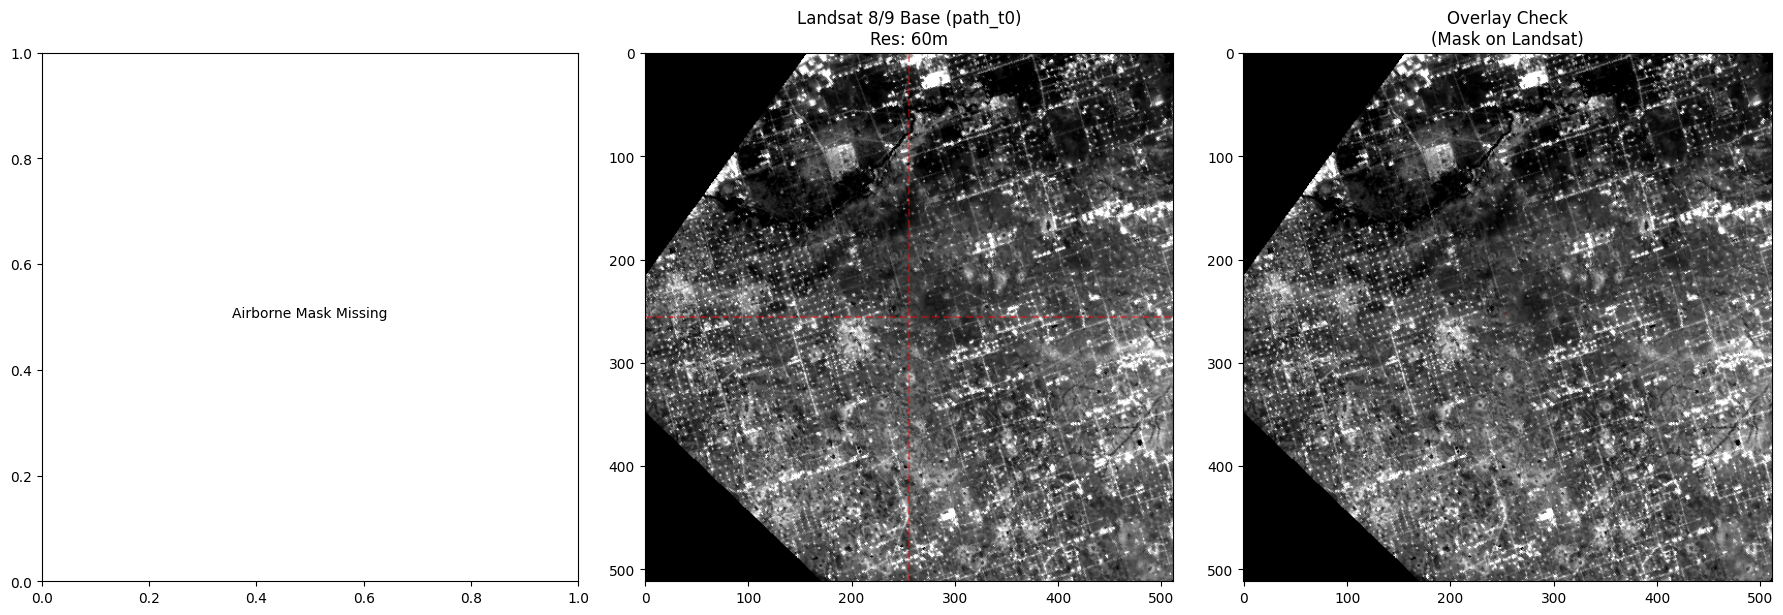

Current Path: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230819t193458p0000-G_sim_L9.tif
----------------------------------------
Processing Plume: GAO20230819t193458p0000-G
Landsat Shape: (512, 512) | Mask Shape: (512, 512)
Plume GAO20230819t193458p0000-G occupies 8 pixels at 60m resolution.
Estimated area: 28800 square meters.


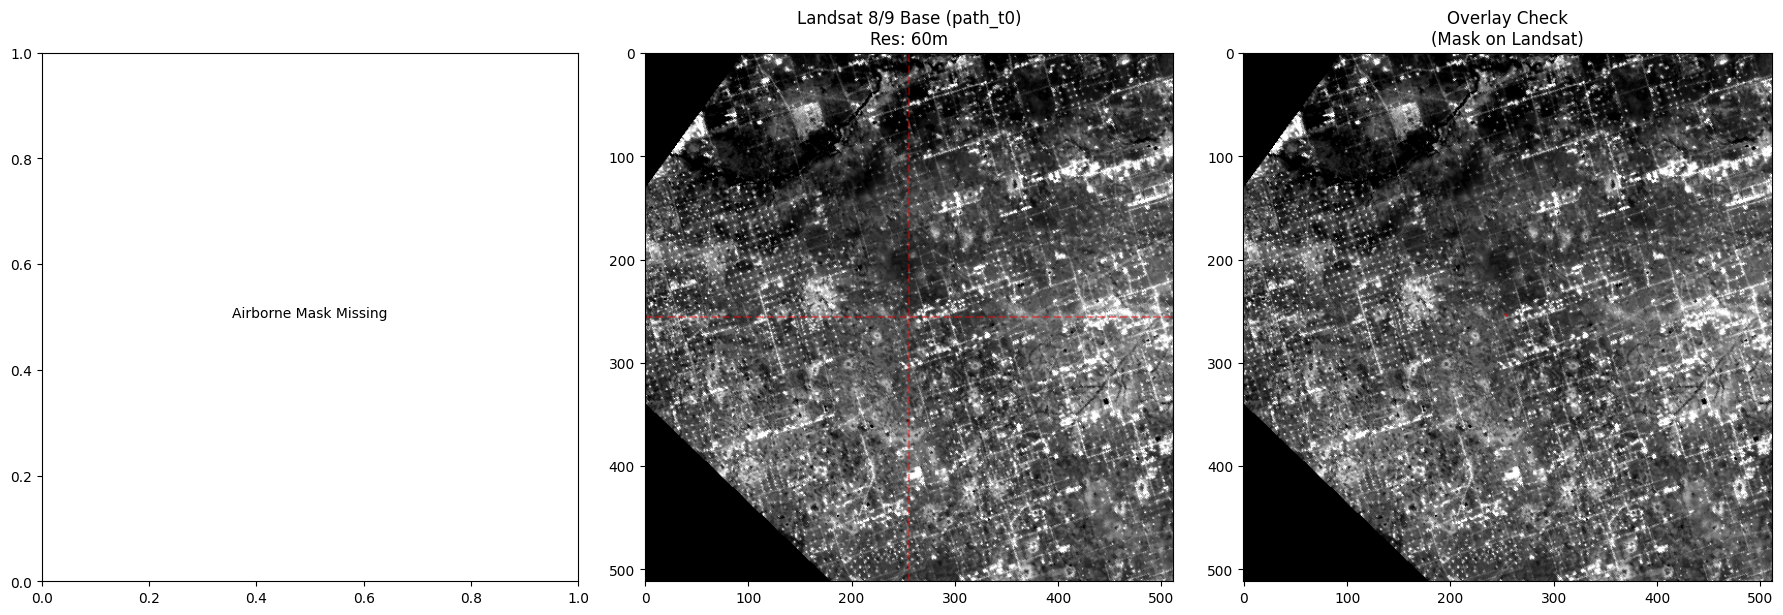

Current Path: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230819t193458p0000-N_sim_L9.tif
----------------------------------------
Processing Plume: GAO20230819t193458p0000-N
Landsat Shape: (512, 512) | Mask Shape: (512, 512)
Plume GAO20230819t193458p0000-N occupies 0 pixels at 60m resolution.
Estimated area: 0 square meters.


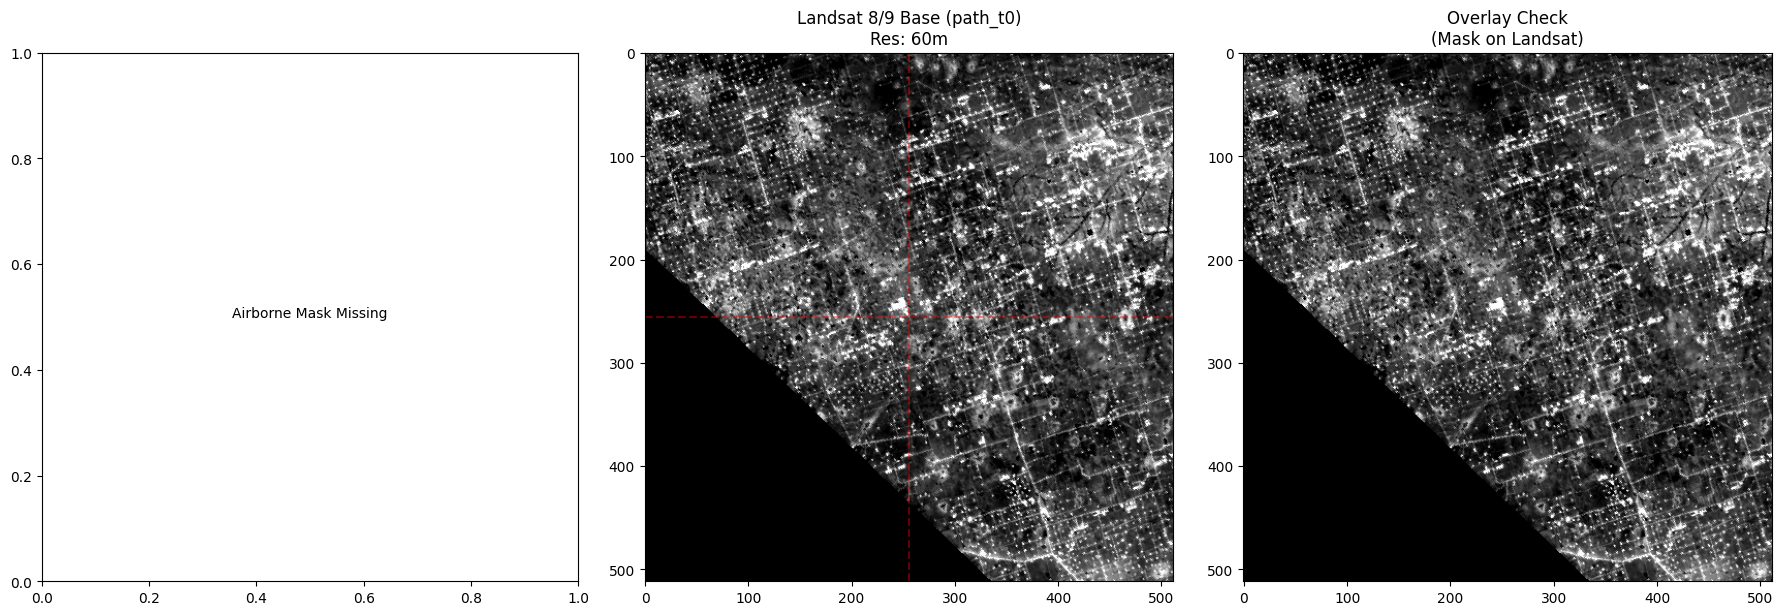

Current Path: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230819t193458p0000-T_sim_L9.tif
----------------------------------------
Processing Plume: GAO20230819t193458p0000-T
Landsat Shape: (512, 512) | Mask Shape: (512, 512)
Plume GAO20230819t193458p0000-T occupies 3 pixels at 60m resolution.
Estimated area: 10800 square meters.


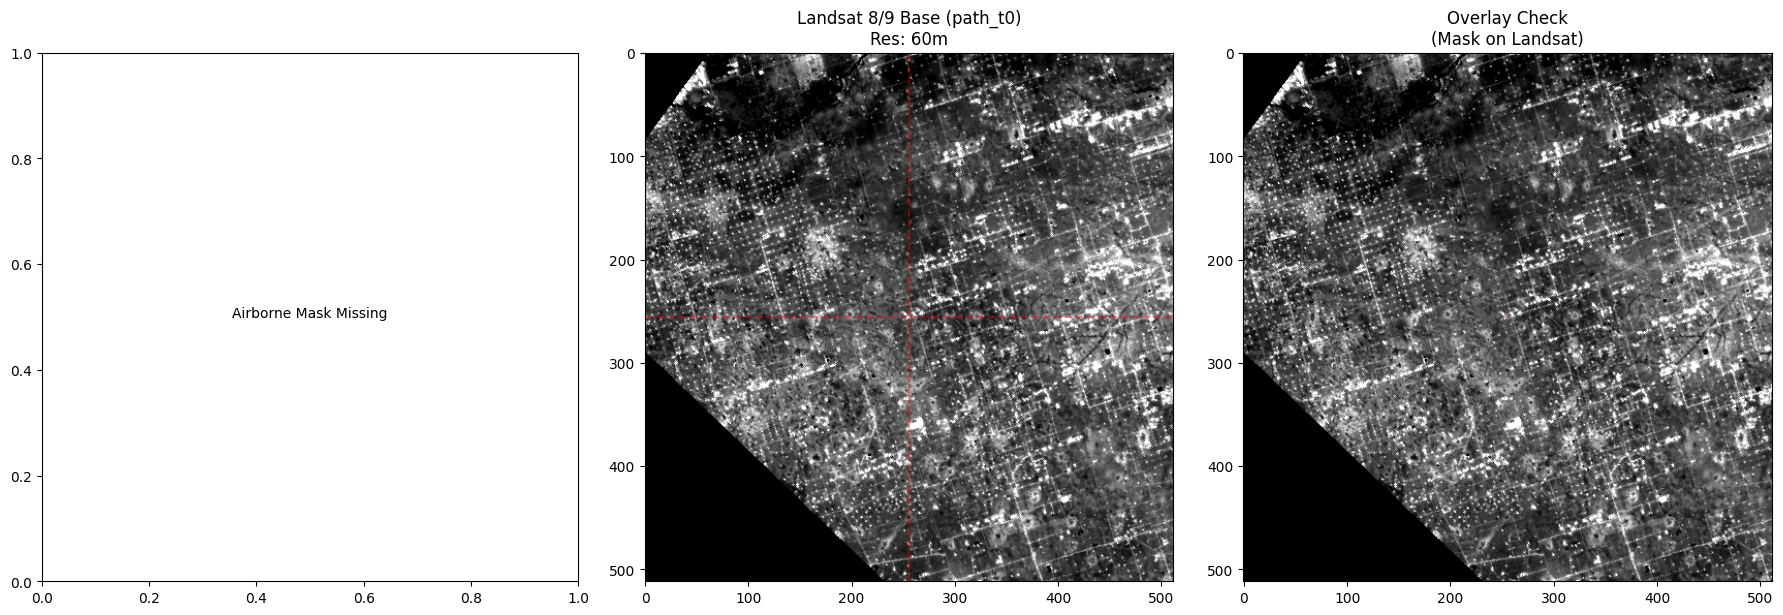

Current Path: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230819t194058p0000-A_sim_L9.tif
----------------------------------------
Processing Plume: GAO20230819t194058p0000-A
Landsat Shape: (512, 512) | Mask Shape: (512, 512)
Plume GAO20230819t194058p0000-A occupies 23 pixels at 60m resolution.
Estimated area: 82800 square meters.


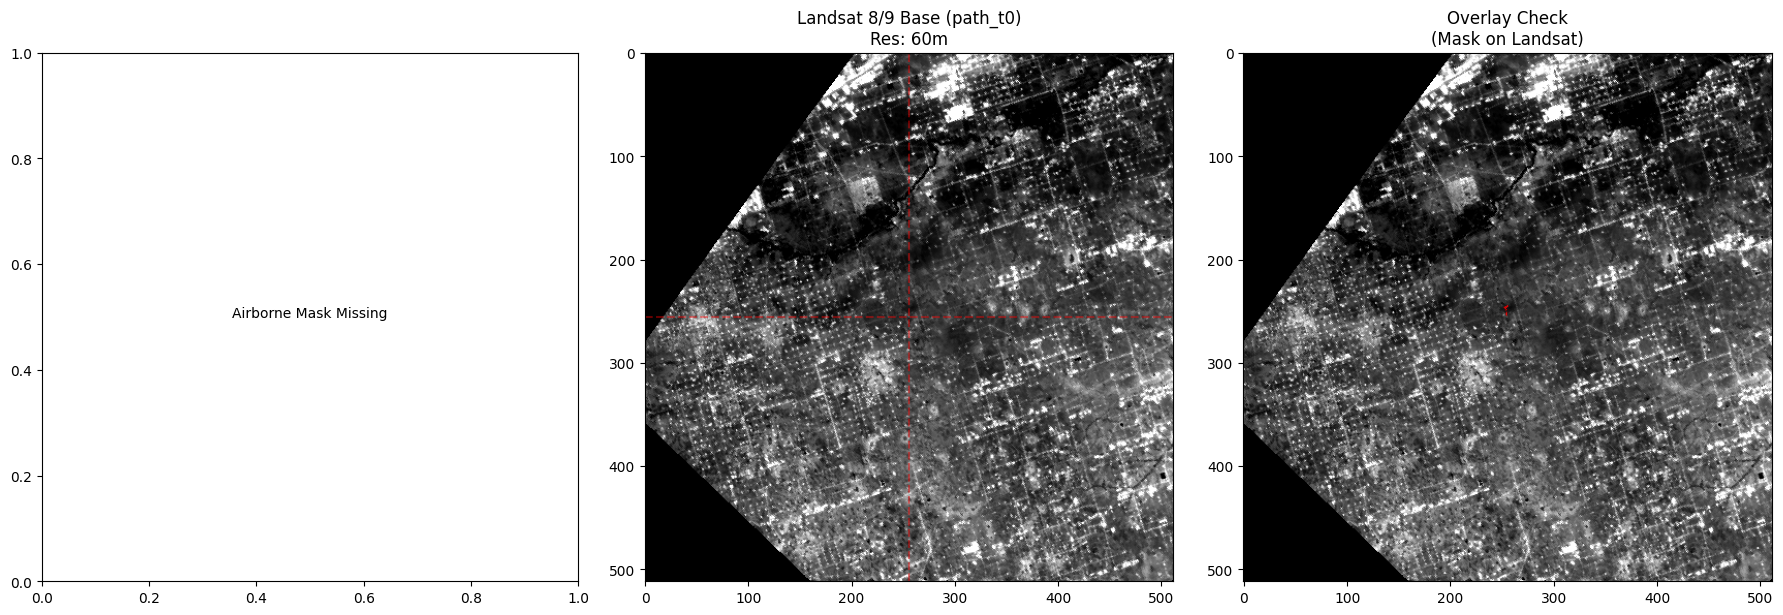

In [4]:
# check the generated masks against satellite images
import pandas as pd
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer

# =========================
# 路径配置
# =========================
# 包含 path_t0 等路径的新 CSV 文件
CSV_PATH = './merged_with_simulated_path_permian_basin.csv' 
# 处理后的 60m 掩膜根目录
MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'
# 原始高分辨率航空掩膜根目录
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

def load_and_preprocess_landsat(path):
    """读取 Landsat 影像并进行鲁棒性归一化"""
    if not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        # 读取第一波段
        data = src.read(1).astype(float)
        
        # 排除无效值 (通常为 0 或 -9999)
        valid_mask = data > 0
        if not np.any(valid_mask):
            return np.zeros_like(data)
        
        # 使用 2% 和 98% 分位数拉伸对比度，防止全白
        vmin, vmax = np.percentile(data[valid_mask], [2, 98])
        data_clipped = np.clip(data, vmin, vmax)
        data_norm = (data_clipped - vmin) / (vmax - vmin + 1e-6)
        return data_norm

def get_data(path):
    """通用读取单波段数据"""
    if os.path.exists(path):
        with rasterio.open(path) as src:
            return src.read(1)
    return None

# 读取数据
df = pd.read_csv(CSV_PATH)
count = 0

for index, row in df.iterrows():
    pid = row['plume_id']
    l89_t0_path = row['simulated_512_path']
    print(f"Current Path: {l89_t0_path}") # Check if this changes every loop
    
    # 路径构建
    airborne_mask_path = os.path.join(BASE_AIRBORNE_DIR, pid, 'plume.tif')
    resized_mask_path = os.path.join(MASK_ROOT, pid, 'mask_60m_512.tif')

    # 读取三方数据
    img_airborne = get_data(airborne_mask_path)
    img_resized = get_data(resized_mask_path)
    img_landsat = load_and_preprocess_landsat(l89_t0_path)

    # 如果关键数据缺失，跳过
    if img_landsat is None:
        print(f"Skipping {pid}: Landsat image not found at {l89_t0_path}")
        continue

    print("-" * 40)
    print(f"Processing Plume: {pid}")
    print(f"Landsat Shape: {img_landsat.shape} | Mask Shape: {img_resized.shape if img_resized is not None else 'N/A'}")

    if img_resized is not None:
        # Count non-zero pixels in the 60m mask
        pixel_count = np.count_nonzero(img_resized > 0)
        print(f"Plume {pid} occupies {pixel_count} pixels at 60m resolution.")
        
        # Calculate physical area in square meters
        physical_area = pixel_count * 3600
        print(f"Estimated area: {physical_area} square meters.")
    
    # 开始绘图
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 图1: 原始航空掩膜 (验证数据源)
    if img_airborne is not None:
        axes[0].imshow(img_airborne, cmap='viridis')
        axes[0].set_title(f"Original Airborne Mask\n{pid}")
    else:
        axes[0].text(0.5, 0.5, 'Airborne Mask Missing', ha='center')

    # 图2: Landsat 8/9 真实底图 (验证底图是否正确读取)
    axes[1].imshow(img_landsat, cmap='gray')
    axes[1].set_title(f"Landsat 8/9 Base (path_t0)\nRes: 60m")
    # 画中心十字线
    axes[1].axhline(img_landsat.shape[0]//2, color='red', linestyle='--', alpha=0.4)
    axes[1].axvline(img_landsat.shape[1]//2, color='red', linestyle='--', alpha=0.4)

    # In the 圖3: 叠加显示 section:
    if img_resized is not None:
        # Resize if necessary
        if img_resized.shape != img_landsat.shape:
            from skimage.transform import resize
            img_resized_disp = resize(img_resized, img_landsat.shape, order=0, preserve_range=True)
        else:
            img_resized_disp = img_resized

        # Binarize the mask to ensure visibility (anything above 0 is the plume)
        binary_mask = (img_resized_disp > 0).astype(float)

        # Mask out the zeros for transparency
        masked_overlay = np.ma.masked_where(binary_mask == 0, binary_mask)

        axes[2].imshow(img_landsat, cmap='gray')
        # Use 'autumn' or 'Reds' to make it stand out against the grey background
        axes[2].imshow(masked_overlay, cmap='autumn', alpha=0.8) 
        axes[2].set_title("Overlay Check\n(Mask on Landsat)")
    else:
        # This is what you are currently seeing
        axes[2].imshow(img_landsat, cmap='gray')
        axes[2].set_title("Error: Mask File Not Found")

    plt.tight_layout()
    plt.show()

    count += 1
    if count >= 5: # 仅检查前5个样本
        break

--- Raw Data Stats for: GAO20230819t193458p0000-A_sim_L9.tif ---
Band 1: Min=0.0000, Max=19602.0000, Mean=8657.2718
Band 2: Min=0.0000, Max=20796.0000, Mean=9607.2278
Band 3: Min=0.0000, Max=22123.0000, Mean=11540.1663
Band 4: Min=0.0000, Max=26160.0000, Mean=14762.9442
Band 5: Min=0.0000, Max=33263.0000, Mean=18177.9111
Band 6: Min=0.0000, Max=49196.0000, Mean=22797.0408
Band 7: Min=0.0000, Max=65535.0000, Mean=21216.5558


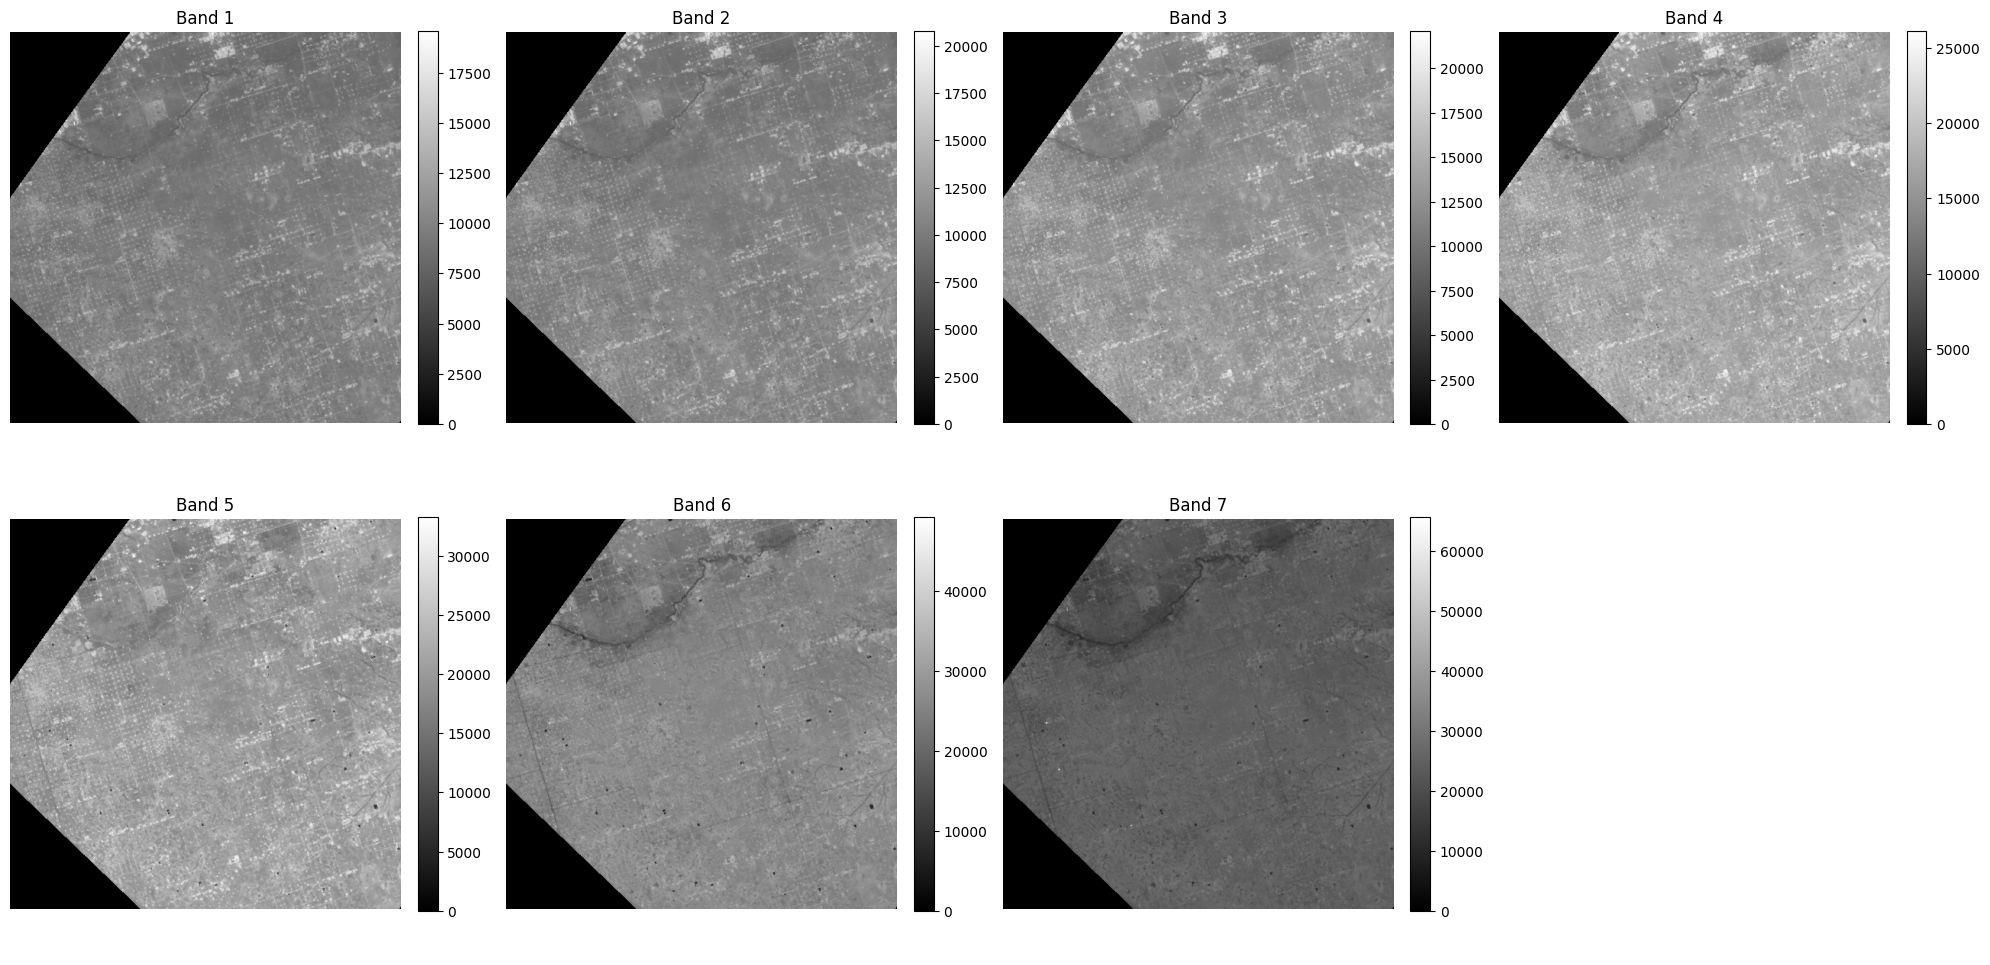

In [5]:
import pandas as pd
import numpy as np
import tifffile
import matplotlib.pyplot as plt

def check_raw_bands(csv_path, row_index=0):
    df = pd.read_csv(csv_path)
    img_path = df.iloc[row_index]['simulated_512_path']
    
    # Load raw data
    data = tifffile.imread(img_path) # Shape (7, 512, 512)
    data = data.transpose(2, 0, 1)
    print(f"--- Raw Data Stats for: {os.path.basename(img_path)} ---")
    for i in range(data.shape[0]):
        band_data = data[i]
        print(f"Band {i+1}: Min={band_data.min():.4f}, Max={band_data.max():.4f}, Mean={band_data.mean():.4f}")

    # Plotting first 7 bands individually to verify content
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i in range(7):
        # We use a simple 'gray' cmap. 
        # Note: If values are 0-1, plt.imshow handles it. 
        # If values are 0-65535, it scales automatically for the view.
        im = axes[i].imshow(data[i], cmap='gray')
        axes[i].set_title(f"Band {i+1}")
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
        axes[i].axis('off')

    axes[7].axis('off') # Hide extra subplot
    plt.tight_layout()
    plt.show()

CSV_FILE = "./merged_with_simulated_path_permian_basin.csv"
check_raw_bands(CSV_FILE, row_index=0)

In [26]:
import pandas as pd

# Load data
df = pd.read_csv('/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_16_resized_to_224_CRSfixed/test_2025_balanced.csv')

# Create the prefix column
df['plume_prefix'] = df['plume_id'].str.split('-').str[0]

# Keep only the FIRST instance of each prefix (removes A/B/C/G/T duplicates)
df_unique_events = df.drop_duplicates(subset=['plume_prefix'], keep='first')

print(f"Original rows: {len(df)}")
print(f"Unique event rows: {len(df_unique_events)}")

Original rows: 10784
Unique event rows: 157


In [ ]:
import pandas as pd

# 1) 读数据（有经纬度 + 时间）
df = pd.read_csv("./merged_with_emit_tag.csv")
# df = pd.read_csv("./CM_L89_L2SR_std512.csv")
# df = pd.read_csv("./l89_emit_overlap_summary.csv")

# 2) Permian basin bbox（请替换为你认可的范围）
# 示例：min_lon, max_lon, min_lat, max_lat
min_lon, max_lon = -105.5, -100.0
min_lat, max_lat =  30.0,  34.5

# 3) 时间过滤（2024-12-31 以前）
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
time_mask = df["datetime"] < pd.Timestamp("2024-12-31T23:59:59Z")

# 4) 空间过滤（Permian basin）
space_mask = (
    (df["plume_longitude"] >= min_lon) & (df["plume_longitude"] <= max_lon) &
    (df["plume_latitude"]  >= min_lat) & (df["plume_latitude"]  <= max_lat)
)
df=df[time_mask & space_mask]
# df.to_csv("./emit_permian_basin_2024.csv", index=False)
count = (time_mask & space_mask).sum()
print("Permian basin 且 2024-12-31 以前的数据数量:", int(count))

Permian basin 且 2024-12-31 以前的数据数量: 550


In [11]:
import pandas as pd
import os

# Paths
EMIT_SIM_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9"
CSV_PATH = "./emit_permian_basin_2024.csv" # Your CSV with the columns provided
MASK_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512"

df = pd.read_csv(CSV_PATH)

def get_paths(pid):
    sim_tif = os.path.join(EMIT_SIM_DIR, f"{pid}_sim_L9.tif")
    mask_tif = os.path.join(MASK_ROOT, str(pid), 'mask_30m_512.tif')
    return sim_tif if os.path.exists(sim_tif) else None, mask_tif if os.path.exists(mask_tif) else None

df[['sim_path', 'mask_path']] = df['plume_id'].apply(lambda x: pd.Series(get_paths(x)))
df = df.dropna(subset=['sim_path', 'mask_path'])
df.to_csv(CSV_PATH, index=False)

In [7]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import threading

# =========================
# Config
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Updated Directory Name
BASE_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025"
INPUT_CSV = "./merged_with_simulated_path_permian_basin.csv"
MANIFEST_PATH = os.path.join(BASE_DIR, "dataset_manifest.csv")

CROP_SIZE = 32       
TARGET_SIZE = 224    
MISSING_THRESH = 0.25
N_POS, N_NEG = 16, 16
NUM_WORKERS = 8
CENTER_BOX = 8      # How much the "center" can jiggle (at 60m pixels)

os.makedirs(BASE_DIR, exist_ok=True)
counter_lock = threading.Lock()
global_cnt = 0

# =========================
# Helpers
# =========================

def ensure_chw(img):
    if img.ndim == 2: return img[np.newaxis, ...]
    if img.ndim == 3 and img.shape[0] > img.shape[2]: return img.transpose(2, 0, 1)
    return img

def upsample_to_224(crop_np):
    with torch.no_grad():
        img_t = torch.from_numpy(crop_np.astype(np.float32)).to(DEVICE).unsqueeze(0)
        img_t = torch.nan_to_num(img_t, nan=0.0)
        upsampled = F.interpolate(img_t, size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        return upsampled.squeeze(0).cpu().numpy()

# =========================
# Worker Core Logic
# =========================

def worker(row):
    global global_cnt
    local_results = []
    pid = row["plume_id"]
    sim_path = row["simulated_512_path"]

    # Debug check
    if not os.path.exists(sim_path):
        return []

    try:
        ref_60m = ensure_chw(tifffile.imread(sim_path).astype(np.float32))
        _, H, W = ref_60m.shape
    except Exception:
        return []

    # Center coordinates logic (assuming plume is at 256, 256)
    # Range of top-left corners that keep the center inside the 32x32 crop
    p_min = (H // 2) - (CROP_SIZE // 2) - (CENTER_BOX // 2)
    p_max = (H // 2) - (CROP_SIZE // 2) + (CENTER_BOX // 2)

    # --- POSITIVE SAMPLES (Always Labeled 1) ---
    for _ in range(N_POS):
        # Randomly jiggle the crop around the center
        x, y = random.randint(p_min, p_max), random.randint(p_min, p_max)
        
        ref_crop = ref_60m[:, y:y+CROP_SIZE, x:x+CROP_SIZE]
        
        # Quality check only (no mask check)
        if ref_crop.size == 0 or (np.isnan(ref_crop[0]) | (ref_crop[0] == 0)).mean() > MISSING_THRESH:
            continue
            
        final_ref = upsample_to_224(ref_crop)

        with counter_lock:
            global_cnt += 1
            sample_id = global_cnt
        
        sample_dir = os.path.join(BASE_DIR, f"sample_{sample_id:06d}")
        os.makedirs(sample_dir, exist_ok=True)
        
        # Feature names modified as requested
        tifffile.imwrite(os.path.join(sample_dir, "reflectance_60m_upsampled.tif"), final_ref)

        local_results.append({
            "sample_id": sample_id, 
            "label": 1, 
            "plume_id": pid,
            "data_path": sample_dir, 
            "timestamp": row["datetime"]
        })

    # --- NEGATIVE SAMPLES (Labeled 0) ---
    neg_attempts = 0
    while len(local_results) < (N_POS + N_NEG) and neg_attempts < 100:
        neg_attempts += 1
        x, y = random.randint(0, W - CROP_SIZE), random.randint(0, H - CROP_SIZE)
        
        # Avoid the center plume area (buffer of 10 pixels)
        if (p_min - 10 <= x <= p_max + 10) and (p_min - 10 <= y <= p_max + 10):
            continue

        ref_crop = ref_60m[:, y:y+CROP_SIZE, x:x+CROP_SIZE]
        if ref_crop.size == 0 or (np.isnan(ref_crop[0]) | (ref_crop[0] == 0)).mean() > MISSING_THRESH:
            continue

        final_ref = upsample_to_224(ref_crop)
        
        with counter_lock:
            global_cnt += 1
            sample_id = global_cnt

        sample_dir = os.path.join(BASE_DIR, f"sample_{sample_id:06d}")
        os.makedirs(sample_dir, exist_ok=True)
        
        tifffile.imwrite(os.path.join(sample_dir, "reflectance_60m_upsampled.tif"), final_ref)
        
        local_results.append({
            "sample_id": sample_id, 
            "label": 0, 
            "plume_id": pid,
            "data_path": sample_dir, 
            "timestamp": row["datetime"]
        })

    return local_results

# =========================
# Main
# =========================

def process_all():
    global global_cnt
    df = pd.read_csv(INPUT_CSV)
    
    # Filter to unique events if you want to avoid processing -A, -G, -T separately
    # df['prefix'] = df['plume_id'].str.split('-').str[0]
    # df = df.drop_duplicates(subset=['prefix'])

    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        rows = [row for _, row in df.iterrows()]
        batch_results = list(tqdm(executor.map(worker, rows), total=len(rows)))

    all_results = [res for sublist in batch_results for res in sublist]
    
    if all_results:
        final_df = pd.DataFrame(all_results)
        final_df.to_csv(MANIFEST_PATH, index=False)
        print(f"Success. Generated {len(final_df)} classification samples.")
    else:
        print("No samples generated. Check paths.")

if __name__ == "__main__":
    process_all()

100%|██████████| 726/726 [13:02<00:00,  1.08s/it]  

Success. Generated 23111 classification samples.


In [8]:
import pandas as pd

# 读csv（换成你的路径）
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/dataset_manifest.csv")

# 拼接新列
df["path_t0"] = df["data_path"].astype(str) + "/reflectance_60m_upsampled.tif"

# 保存
df.to_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/dataset_manifest.csv", index=False)

print(df[["path_t0"]].head())

                                             path_t0
0  /mnt/engg-leung/Research_No9_Methane_Emissions...
1  /mnt/engg-leung/Research_No9_Methane_Emissions...
2  /mnt/engg-leung/Research_No9_Methane_Emissions...
3  /mnt/engg-leung/Research_No9_Methane_Emissions...
4  /mnt/engg-leung/Research_No9_Methane_Emissions...


In [ ]:
import pandas as pd

# 1) 读数据（有经纬度 + 时间）
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/dataset_manifest.csv")
# df = pd.read_csv("./CM_L89_L2SR_std512.csv")
# df = pd.read_csv("./l89_emit_overlap_summary.csv")

# 2) Permian basin bbox（请替换为你认可的范围）
# 示例：min_lon, max_lon, min_lat, max_lat
min_lon, max_lon = -105.5, -100.0
min_lat, max_lat =  30.0,  34.5

# 3) 时间过滤（2024-12-31 以前）
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
time_mask = df["datetime"] < pd.Timestamp("2024-12-31T23:59:59Z")

# 4) 空间过滤（Permian basin）
space_mask = (
    (df["longitude"] >= min_lon) & (df["longitude"] <= max_lon) &
    (df["latitude"]  >= min_lat) & (df["latitude"]  <= max_lat)
)
df=df[time_mask & space_mask]
df.to_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/dataset_manifest_permian_basin.csv", index=False)
count = (time_mask & space_mask).sum()
print("Permian basin 且 2024-12-31 以前的数据数量:", int(count))

Permian basin 且 2024-12-31 以前的数据数量: 9633


In [15]:
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/dataset_manifest.csv")
# print(df2.head())
# df2['date'] = pd.to_datetime(df2['datetime'])
# train_df = df[(df['date'] < '2024-04-10') | (df['date'] >= '2025-01-01')]  # 2025-04-01
# test_df = df[(df['date'] >= '2024-04-10') & (df['date'] < '2025-01-01')]
# train_df = df[(df['datetime'] < '2024-05-13')]  # 2025-04-01
# test_df = df[(df['datetime'] >= '2024-05-13') & (df['datetime'] <= '2024-12-31')]
train_df = df[(df['timestamp'] < '2023-08-25')]  # 2025-04-01
test_df = df[(df['timestamp'] >= '2023-08-25')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')

# train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/train_permian.csv'
# train_df.to_csv(train_csv, index=False)
# print(f'train set size {len(train_df)}')

# test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_60m_to_224_classification_2025/test_permian.csv'
# test_df.to_csv(test_csv, index=False)
# print(f'test set size {len(test_df)}')

print(train_df['label'].sum()/len(train_df), test_df['label'].sum()/len(test_df))

training set 19905 testing set 3206 train ratio 0.861
0.484652097462949 0.4750467872738615


In [2]:
import pandas as pd
df_sim=pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/emit_sim_32_to_224_permian_basin_2024/dataset_manifest.csv")
df_real=pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/dataset_manifest_permian_basin.csv")
df_real = df_real[df_sim.columns]
df=pd.concat([df_sim,df_real],ignore_index=True)
train_df_sim = df_sim[(df_sim['datetime'] < '2023-10-25') & (df_sim['datetime'] > '2023-08-21')]  # 2025-04-01
test_df_sim = df_sim[(df_sim['datetime'] >= '2023-10-25') & (df_sim['datetime'] <= '2024-12-31')]
print(f'sim training set {len(train_df_sim)} testing set {len(test_df_sim)} train ratio {len(train_df_sim)/(len(train_df_sim)+len(test_df_sim)):.3f}')
train_df_real = df_real[(df_real['datetime'] < '2024-05-13')]  # 2025-04-01
test_df_real = df_real[(df_real['datetime'] >= '2024-05-13') & (df_real['datetime'] <= '2024-12-31')]
print(f'real training set {len(train_df_real)} testing set {len(test_df_real)} train ratio {len(train_df_real)/(len(train_df_real)+len(test_df_real)):.3f}')
# train_df = pd.concat([train_df_sim, train_df_real], ignore_index=True)
# test_df = pd.concat([test_df_sim, test_df_real], ignore_index=True)
# print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')
# id,label,plume_id,path,datetime
# id,label,plume_id,path,latitude,longitude,datetime,path_t0,path_t90,path_t360

# train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train_sim_real_mix_permian.csv'
# train_df.to_csv(train_csv, index=False)
# print(f'train set size {len(train_df)}')

# test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/test_sim_real_mix_permian.csv'
# test_df.to_csv(test_csv, index=False)
# print(f'test set size {len(test_df)}')

train_sim_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/train_sim_permian.csv'
train_df_sim.to_csv(train_sim_csv, index=False)
print(f'train set size {len(train_df_sim)}')

test_sim_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224/test_sim_permian.csv'
test_df_sim.to_csv(test_sim_csv, index=False)
print(f'test set size {len(test_df_sim)}')

print(train_df_sim['label'].sum()/len(train_df_sim), test_df_sim['label'].sum()/len(test_df_sim))

sim training set 7381 testing set 2822 train ratio 0.723
real training set 6773 testing set 2860 train ratio 0.703
train set size 7381
test set size 2822
0.4890936187508468 0.4907866761162296


In [23]:
import os
import gc
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import earthaccess
import cupy as cp
from pathlib import Path
from pyproj import Transformer
from scipy.spatial import KDTree as CPU_KDTree

# ==================== 用户配置区 ====================
CSV_PATH = "./merged_with_emit_tag.csv"
SRF_CSV = "./landsat9_oli_srf.csv"
EMIT_RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT")
# OUTPUT_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution")
OUTPUT_DIR = Path("./")
CHIP_SIZE_PX = 512
SCALE_M = 60
# ===================================================

EMIT_RAW_DIR.mkdir(exist_ok=True, parents=True)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def get_utm_crs(lat, lon):
    zone = int((lon + 180) / 6) + 1
    return f"EPSG:{32600 + zone if lat >= 0 else 32700 + zone}"

def get_spectral_matrix_physics(emit_waves, srf_df, solar_irr_nc=None):
    """
    计算考虑太阳能量分布的光谱矩阵
    """
    if solar_irr_nc is not None:
        solar_irr = solar_irr_nc
    else:
        # 如果nc文件里没有，构造简易太阳曲线：可见光(500nm附近)最强，SWIR逐渐减弱
        print("   [Info] No solar_irradiance in NC, using empirical solar curve.")
        solar_irr = np.ones_like(emit_waves)
        solar_irr[emit_waves < 400] = 1.5
        solar_irr[(emit_waves >= 400) & (emit_waves < 700)] = 2.0 
        solar_irr[(emit_waves >= 700) & (emit_waves < 1300)] = 1.2
        solar_irr[(emit_waves >= 1300) & (emit_waves < 1900)] = 0.6
        solar_irr[emit_waves >= 1900] = 0.3

    matrix = np.zeros((len(emit_waves), 7))
    for i in range(1, 8):
        srf_interp = np.interp(emit_waves, srf_df["wavelength"], srf_df[f"b{i}"], left=0, right=0)
        # 物理权重 = 响应函数 * 太阳辐照度
        weight = srf_interp * solar_irr
        denom = weight.sum()
        if denom > 0:
            matrix[:, i-1] = weight / denom
            
    return cp.array(matrix)

def process_single_plume(plume_id_target, df, srf_df):
    # 查找CSV中的元数据
    target_rows = df[df['plume_id'] == plume_id_target]
    if target_rows.empty:
        print(f"   [Error] {plume_id_target} not found in CSV.")
        return
    row = target_rows.iloc[0]

    # 硬编码你指定的 NC 路径
    rfl_path = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_EMIT/EMIT_L2A_RFL_001_20230824T175337_2323612_023.nc"
    out_tif = OUTPUT_DIR / f"{plume_id_target}_sim_L9_physics.tif"
    
    print(f"\n[Processing Case] {plume_id_target}")

    try:
        # 1. 获取波段参数和辐照度
        solar_irr = None
        with xr.open_dataset(rfl_path, group='sensor_band_parameters') as dsb:
            waves = dsb['wavelengths'].values
            if 'solar_irradiance' in dsb:
                solar_irr = dsb['solar_irradiance'].values
            spec_matrix = get_spectral_matrix_physics(waves, srf_df, solar_irr)

        # 2. 空间裁剪范围
        with xr.open_dataset(rfl_path, group='location') as ds_loc:
            lats, lons = ds_loc['lat'].values, ds_loc['lon'].values
            mask_spatial = (lats > row['plume_latitude'] - 0.15) & (lats < row['plume_latitude'] + 0.15) & \
                           (lons > row['plume_longitude'] - 0.15) & (lons < row['plume_longitude'] + 0.15)
            y_idxs, x_idxs = np.where(mask_spatial)
            y_min, y_max, x_min, x_max = y_idxs.min(), y_idxs.max(), x_idxs.min(), x_idxs.max()
            lat_crop, lon_crop = lats[y_min:y_max, x_min:x_max], lons[y_min:y_max, x_min:x_max]

        # 3. 加载反射率数据
        with xr.open_dataset(rfl_path) as ds:
            rfl_crop = ds['reflectance'][y_min:y_max, x_min:x_max, :].values

        # 4. GPU 卷积与【关键】对比度拉伸
        cp_rfl = cp.array(np.nan_to_num(rfl_crop, 0))
        # sim_result = cp.matmul(cp_rfl, spec_matrix) # (Y, X, 7)
        sim_result = cp_rfl
        
        target_scales = [10100, 11100, 13100, 16100, 20100, 23100, 21100]
        # 对每个波段分别进行 2%-98% 线性拉伸，增加方差（让直方图变宽）
        cp_simulated_list = []
        for b in range(7):
            band_data = sim_result[:, :, b]
            # 剔除 0 值后再计算百分位，防止背景干扰
            valid_mask = (band_data > 0)
            if valid_mask.any():
                p_low = cp.percentile(band_data[valid_mask], 1)
                p_high = cp.percentile(band_data[valid_mask], 99)
            else:
                p_low, p_high = 0, 1

            # 线性拉伸
            stretched = (band_data - p_low) / (p_high - p_low + 1e-6)
            
            # 使用对应波段的目标量级进行缩放，并加上一个基础偏移量
            # 基础偏移量（Offset）是为了让直方图的左侧对齐蓝色的左侧
            offset = target_scales[b] * 0.8  
            final_band = (stretched * (target_scales[b] * 0.6)) + offset
            
            cp_simulated_list.append(cp.clip(final_band, 0, 65535))
        
        # 堆叠回 (7, Y, X)
        cp_simulated = cp.stack(cp_simulated_list, axis=0)

        # 5. KDTree 重采样
        utm_epsg = get_utm_crs(row['plume_latitude'], row['plume_longitude'])
        to_utm = Transformer.from_crs("EPSG:4326", utm_epsg, always_xy=True)
        to_wgs = Transformer.from_crs(utm_epsg, "EPSG:4326", always_xy=True)
        
        center_x, center_y = to_utm.transform(row['plume_longitude'], row['plume_latitude'])
        half_size = (CHIP_SIZE_PX * SCALE_M) / 2
        target_x = np.linspace(center_x - half_size, center_x + half_size, CHIP_SIZE_PX)
        target_y = np.linspace(center_y + half_size, center_y - half_size, CHIP_SIZE_PX)
        
        mesh_x, mesh_y = np.meshgrid(target_x, target_y)
        t_lon, t_lat = to_wgs.transform(mesh_x, mesh_y)
        
        tree = CPU_KDTree(np.stack([lat_crop.ravel(), lon_crop.ravel()], axis=1))
        dist, indices = tree.query(np.stack([t_lat.ravel(), t_lon.ravel()], axis=1), distance_upper_bound=0.001)
        
        # 6. 映射与保存
        cp_indices = cp.array(indices)
        final_output = cp_simulated.reshape(7, -1)[:, cp_indices].reshape(7, CHIP_SIZE_PX, CHIP_SIZE_PX)
        invalid_mask = cp.array(dist == float('inf')).reshape(CHIP_SIZE_PX, CHIP_SIZE_PX)
        final_output[:, invalid_mask] = 0
        
        res_np = final_output.get().astype(np.uint16)

        sim_da = xr.DataArray(res_np, dims=("band", "y", "x"), 
                             coords={"band": np.arange(1, 8), "y": target_y, "x": target_x})
        sim_da.rio.write_crs(utm_epsg, inplace=True)
        sim_da.rio.to_raster(out_tif)
        
        print(f"   [Success] Saved to: {out_tif}")
        print(f"   [Stats] Min: {res_np.min()}, Max: {res_np.max()}, Mean: {res_np.mean():.1f}")

    except Exception as e:
        print(f"   [Error] {plume_id_target} failed: {e}")
    finally:
        cp.get_default_memory_pool().free_all_blocks()
        gc.collect()

if __name__ == "__main__":
    df = pd.read_csv(CSV_PATH)
    srf_df = pd.read_csv(SRF_CSV)
    
    # 运行指定案例
    test_id = "GAO20230824t160435p0000-C"
    process_single_plume(test_id, df, srf_df)


[Processing Case] GAO20230824t160435p0000-C
   [Info] No solar_irradiance in NC, using empirical solar curve.
   [Success] Saved to: GAO20230824t160435p0000-C_sim_L9_physics.tif
   [Stats] Min: 0, Max: 52359, Mean: 15281.7


Real data has 10 bands, slicing to first 7.


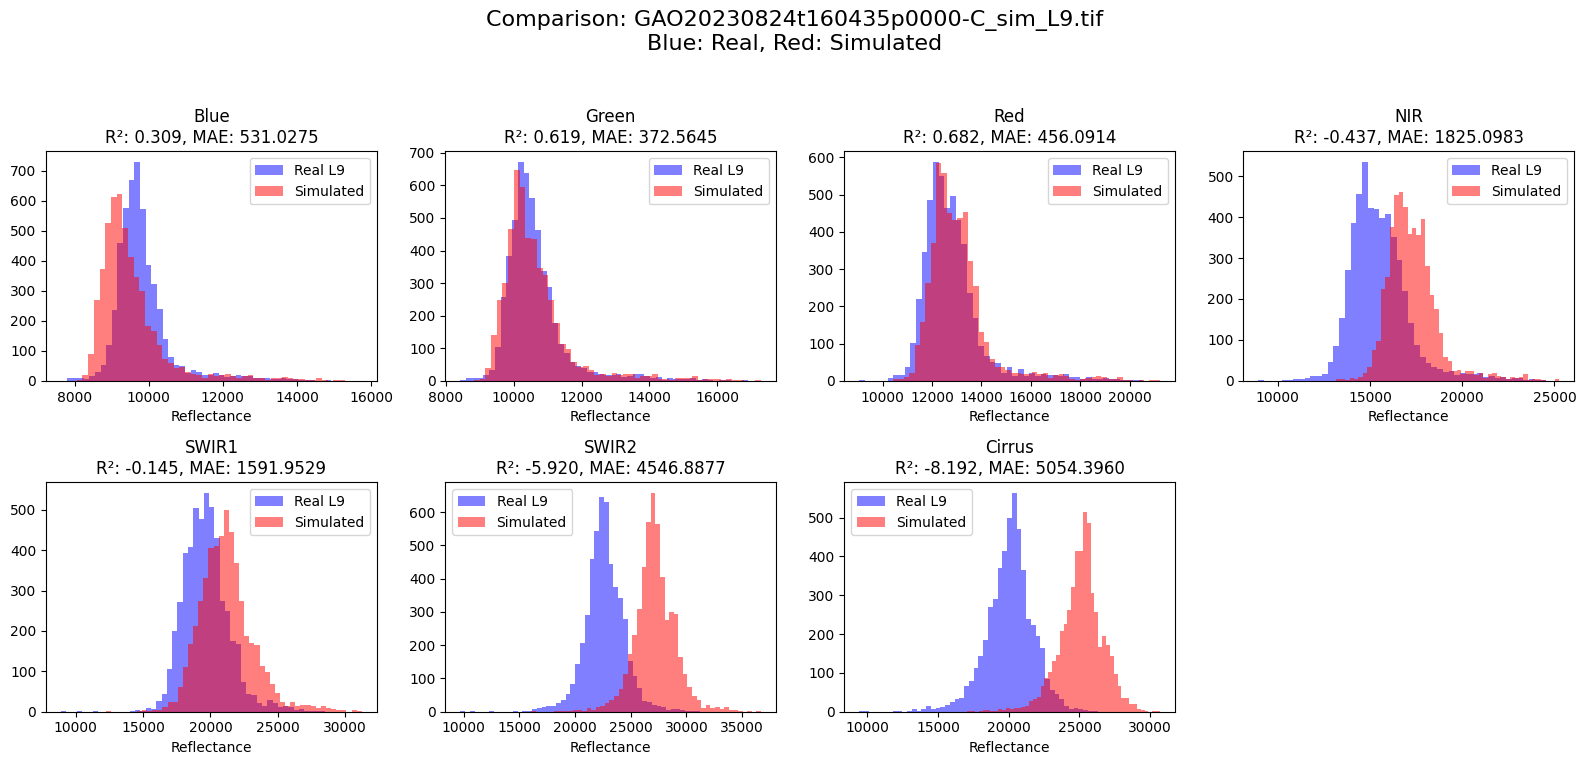

In [6]:
import numpy as np
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import os

def compare_landsat_sim(sim_path, real_path):
    # 1. 读取数据
    sim_da = rioxarray.open_rasterio(sim_path)
    real_da = rioxarray.open_rasterio(real_path)

    # 【核心修改】：强制只取前 7 个波段
    # 如果 real_da 维度是 (band, y, x)，我们切片取 [:7]
    if real_da.shape[0] > 7:
        print(f"Real data has {real_da.shape[0]} bands, slicing to first 7.")
        real_da = real_da.isel(band=slice(0, 7))
    elif real_da.shape[0] < 7:
        print(f"Warning: Real data only has {real_da.shape[0]} bands!")

    # 2. 空间对齐 (将 Landsat 重采样到模拟数据的网格上)
    # real_aligned 的维度将与 sim_da 完全一致
    real_aligned = real_da.rio.reproject_match(sim_da)

    # 3. 提取数值
    sim_val = sim_da.values
    real_val = real_aligned.values
    
    # sim_val = sim_val * 10000.0 # 临时放大模拟值用于绘图
    
    # 自动缩放 Landsat：如果是 0-10000 的 Uint16，转为 0-1
    if real_val.max() > 10:
        print("Scaling Real data from digital numbers to reflectance (0-1)...")
        real_val = real_val / 10000.0

    # 4. 统计对比
    bands = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2", "Cirrus"]
    plt.figure(figsize=(16, 8))

    # 确定实际可对比的波段数，防止数组越界
    num_to_compare = min(7, sim_val.shape[0], real_val.shape[0])

    for i in range(num_to_compare):
        # 掩膜处理：剔除无效值（0 或 NaN）
        # 这一步很关键，如果不剔除背景 0 值，R² 会因为包含大量背景而虚高
        mask_i = (sim_val[i] > 0) & (real_val[i] > 0) & \
                 (~np.isnan(sim_val[i])) & (~np.isnan(real_val[i]))
        
        b_sim = sim_val[i][mask_i]
        b_real = real_val[i][mask_i]
        
        if b_sim.size < 10: 
            print(f"Band {i+1} ({bands[i]}) has no overlapping valid pixels.")
            continue

        r2 = r2_score(b_real, b_sim)
        mae = np.mean(np.abs(b_real - b_sim))

        # 绘图：直方图对比
        plt.subplot(2, 4, i+1)
        plt.hist(b_real.ravel(), bins=50, alpha=0.5, label='Real L9', color='blue')
        plt.hist(b_sim.ravel(), bins=50, alpha=0.5, label='Simulated', color='red')
        plt.title(f"{bands[i]}\nR²: {r2:.3f}, MAE: {mae:.4f}")
        plt.xlabel("Reflectance")
        plt.legend()

    sim_filename = os.path.basename(sim_path) # 获取文件名
    plt.suptitle(f"Comparison: {sim_filename}\nBlue: Real, Red: Simulated", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 调用示例
compare_landsat_sim(
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/EMIT_simulated_landsat9_60resolution_NOnorm/GAO20230824t160435p0000-C_sim_L9.tif", 
    "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/L89_-790360_512std/GAO20230824t160435p0000-C/l89_0_std_512.tif"
)